<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/Bo_or_Not_Bo_VGG16_and_FiftyOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Binary Classification with Transfer Learning: Bo or not Bo


Bo [was Barack Obama's dog](https://en.wikipedia.org/wiki/Bo_(dog)). He was a Portuguese Water Dog.

![](https://i.guim.co.uk/img/media/d702b3c7f292dd26baf23d01b07eac85bdf6addb/0_46_665_399/master/665.jpg?width=700&quality=85&auto=format&fit=max&s=6a96387dcd37d0579571db8a91170349)

Imagine that the secret service wanted at some point in time to create a computer vision system to automatically recognize him from other pets.

We will take that task and use it to explore [transfer learning](https://developers.google.com/machine-learning/glossary#transfer-learning).


## VGG16 and ImageNet

![](https://miro.medium.com/v2/resize:fit:827/1*UeAhoKM0kJfCPA03wt5H0A.png)

[VGG16](https://arxiv.org/abs/1409.1556) is a [convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN) architecture that was introduced by the Visual Geometry Group (VGG) at the University of Oxford.

The "16" in VGG16 refers to the number of learnable [layers](https://developers.google.com/machine-learning/glossary#layer) in the network architecture. These layers include convolutional layers and fully connected layers. It does not count the [pooling layers](https://developers.google.com/machine-learning/glossary#pooling) or [activation functions](https://developers.google.com/machine-learning/glossary#activation_function).

It is known for its simplicity and its use of a stack of small 3x3 convolutional layers, followed by pooling and fully connected layers. [ImageNet](https://www.image-net.org/) is a large-scale dataset of images that is used for training and benchmarking computer vision models. It contains millions of labeled images across thousands of categories. VGG16 was originally trained on the ImageNet dataset, which means it learned to recognize a wide variety of objects and scenes. This pre-training on a large dataset like ImageNet makes VGG16 a powerful feature extractor that can be used for transfer learning on new image classification tasks.

We will use a VGG16 ImageNet-pretrained convolutional network to classify our pet images. We will first explore what the network knows, then we will adapt its architecture to the binary classification task of figuring out whether a pet image is Bo or not.

### Installing FiftyOne

In [66]:
!pip install fiftyone==1.5.2 > /dev/null

## Imports

In [67]:
import os

# Set environment variables for reproducibility BEFORE importing torch
os.environ['PYTHONHASHSEED'] = '51'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fun
import torchvision.transforms.v2 as transforms
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from torch.utils.data import Dataset, ConcatDataset, DataLoader
from fiftyone import ViewField as F
import fiftyone.utils.random as four
from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
import matplotlib.pyplot as plt
import gc
import albumentations as A
import cv2
import random
from typing import Optional, Dict, Tuple, Any
from google.colab import drive
from torchvision.models import vgg16, VGG16_Weights
from torchvision.transforms.functional import InterpolationMode


## Reproducibility for experiments

We want to make our random splits of data and our random weights inside the neural network to be the same in multiple Python sessions. To achieve this, we set seeds for our random number generators.

In [68]:
def set_seeds(seed=51):
    """
    Set seeds for complete reproducibility across all libraries and operations.

    Args:
        seed (int): Random seed value
    """
    # Set environment variables before other imports
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    # Python random module
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU (all devices)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

        # CUDA deterministic operations
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # OpenCV
    cv2.setRNGSeed(seed)

    # Albumentations (for data augmentation)
    try:
        A.seed_everything(seed)
    except AttributeError:
        # Older versions of albumentations
        pass

    # PyTorch deterministic algorithms (may impact performance)
    try:
        torch.use_deterministic_algorithms(True)
    except RuntimeError:
        # Some operations don't have deterministic implementations
        print("Warning: Some operations may not be deterministic")

    print(f"All random seeds set to {seed} for reproducibility")



# Usage: Call this function at the beginning and before each training phase
set_seeds(51)


All random seeds set to 51 for reproducibility


## Setting the computing device

We will set the `device` variable to 'cuda' and use an Nvidia GPU if it's available in our environment.

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

## Obtaining the data from Google Drive

We have a small collection of images of Bo alongside a collection of images of other pets (cats and dogs). Every 'Not-Bo' invidvidual is labeled as `not_bo` in this dataset.

The data available through this [Google Drive link](https://drive.google.com/drive/folders/1EU1ujeNtvsaKAIeyS7J8BDFC60iHvwi1?usp=drive_link).


Follow the instructions [here](https://github.com/andandandand/practical-computer-vision/blob/main/docs/add_shortcut_to_google_drive.md) to access the data without having to download it.

You can also [obtain the data through Kaggle](https://www.kaggle.com/datasets/drvnmanju/presidential-doggy-door).

### Connecting Google Drive to Colab

In [70]:
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [71]:
# Checking the content of our Drive path
!ls /gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog

test  train


In [72]:
parent_path = Path('/gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog')

In [73]:
os.listdir(parent_path / 'train')

['not_bo', 'bo']

In [74]:
os.listdir(parent_path / 'test')

['bo', 'not_bo']

## Creating the FiftyOne Dataset (`bo_dataset`)

A FiftyOne dataset data wraps together media files (image, video) with training labels and all metadata associated with them. It's also a great way to inspect and understand the data splits: train, validation, and testing.

### Preparing train and validation datasets

We split the data into training and validation sets. The training set is used to update the model's weights, and the validation set is used to evaluate the model's performance during training and tune hyperparameters.

In [75]:
# Create the FiftyOne training and validation dataset
training_validation_dataset = fo.Dataset.from_dir(
    dataset_dir=parent_path /'train',
    dataset_type=fo.types.ImageClassificationDirectoryTree,

)
# Split into training and validation
set_seeds(51)
# Create random split using tags
four.random_split(training_validation_dataset,
                  {"train": 0.50, "validation": 0.50},
                  # The seed makes the split reproducible
                  seed=51)

# Verify the split by counting tags
tag_counts = training_validation_dataset.count_sample_tags()
print("Tag counts after split:")
print(tag_counts)

# Separate validation and train FO datasets
train_dataset = training_validation_dataset.match_tags("train").clone()
val_dataset = training_validation_dataset.match_tags("validation").clone()

# Set names for FO datasets using the 'name' property
#train_dataset.name = "bo-training-set"
#val_dataset.name = "bo-validation-set"

# Define persistency
train_dataset.persistent = True
val_dataset.persistent = True

# Verify no overlap between train and validation
train_ids = set(train_dataset.values("id"))
val_ids = set(val_dataset.values("id"))
overlap = train_ids.intersection(val_ids)


 100% |█████████████████| 139/139 [88.9ms elapsed, 0s remaining, 1.6K samples/s]   


INFO:eta.core.utils: 100% |█████████████████| 139/139 [88.9ms elapsed, 0s remaining, 1.6K samples/s]   


All random seeds set to 51 for reproducibility
Tag counts after split:
{'train': 70, 'validation': 69}


The test dataset is where we will report performance benchmarks for the trained model.

In [76]:
# Create the FiftyOne testing dataset
testing_dataset = fo.Dataset.from_dir(
    dataset_dir=parent_path /'test',
    dataset_type=fo.types.ImageClassificationDirectoryTree,

)
print(f'Image in the test set {len(testing_dataset)}')


 100% |███████████████████| 30/30 [28.6ms elapsed, 0s remaining, 1.0K samples/s]      


INFO:eta.core.utils: 100% |███████████████████| 30/30 [28.6ms elapsed, 0s remaining, 1.0K samples/s]      


Image in the test set 30


## Tag and merge datasets

All `Sample` instances (each image or video inside a FiftyOne dataset) [have a `tags` attribute](https://docs.voxel51.com/user_guide/basics.html#tags), which stores a list of strings that can be used to store information about a sample.

A typical use case is to tag the dataset split (test, train, validation) to which the `Sample` belongs.

In [77]:
# First, ensure all datasets have their split tags
train_dataset.tag_samples("train")
val_dataset.tag_samples("validation")
testing_dataset.tag_samples("test")

# Create a new dataset name or use an existing one
dataset_name = "bo-dataset"

if dataset_name in fo.list_datasets():
    bo_dataset = fo.load_dataset(dataset_name)
    print(f"Loading existing dataset: {dataset_name}")
else:
    # Create a new empty dataset to merge into
    bo_dataset = fo.Dataset(dataset_name)
    print(f"Creating new dataset: {dataset_name}")

# Method 1: Use merge_samples() for each dataset
print("Merging train dataset...")
bo_dataset.merge_samples(train_dataset)

print("Merging validation dataset...")
bo_dataset.merge_samples(val_dataset)

print("Merging testing dataset...")
bo_dataset.merge_samples(testing_dataset)

# Verify the merge
print(f"Merged FiftyOne dataset size: {len(bo_dataset)}")
print(f"Tag counts in merged dataset: {bo_dataset.count_sample_tags()}")

# Make the dataset persistent
bo_dataset.persistent = True

Loading existing dataset: bo-dataset
Merging train dataset...
Merging validation dataset...
Merging testing dataset...
Merged FiftyOne dataset size: 169
Tag counts in merged dataset: {'original': 70, 'train': 70, 'validation': 69, 'test': 30}


In [78]:
# Add metadata information to the dataset (image sizes and format)
bo_dataset.compute_metadata()

In [79]:
session = fo.launch_app(bo_dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


![](https://github.com/andandandand/practical-computer-vision/blob/main/images/bo_not_bo_classes_histogram.png?raw=true)

## Apply an Imagenet-pretrained VGG-16 model to the testing dataset



We apply a VGG-16 model, which was trained on the ImageNet dataset, to our testing dataset. This model has learned to recognize many different objects. We use it here to get predictions and embeddings for our images. These predictions show what the model thinks is in each image. The embeddings are numerical representations of the images based on the model's learned features. We will use these to analyze the dataset.

![]()

![]()

In [80]:
model = foz.load_zoo_model("vgg16-imagenet-torch")

# We obtain the predictions of the original model's architecture
bo_dataset.apply_model(model, label_field="vgg16-imagenet-predictions")

 100% |█████████████████| 169/169 [6.7s elapsed, 0s remaining, 23.7 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 169/169 [6.7s elapsed, 0s remaining, 23.7 samples/s]      


In [ ]:
# We compute embeddings from final layers of the model
bo_dataset.compute_embeddings(model=model, embeddings_field='vgg16-imagenet-embeddings')

# We create a similarity index out of the embeddings that we have computed
similarity_index = fob.compute_similarity(
    bo_dataset,
    embeddings="vgg16-imagenet-embeddings",  # Field containing the embeddings
    brain_key="vgg16_imagenet_cosine_similarity_index",  # Unique identifier for this similarity index
    backend="sklearn",
    metric="cosine"  # Similarity metric (cosine is good for embeddings)
)



In [82]:
a_sample = bo_dataset.first()
a_sample

<Sample: {
    'id': '6874e5514bb43cd509913ac2',
    'media_type': 'image',
    'filepath': '/gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog/train/bo/bo_1.jpg',
    'tags': ['train', 'original'],
    'metadata': <ImageMetadata: {
        'size_bytes': 25365,
        'mime_type': 'image/jpeg',
        'width': 236,
        'height': 314,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 7, 14, 11, 9, 5, 292000),
    'last_modified_at': datetime.datetime(2025, 7, 14, 11, 24, 5, 495000),
    'ground_truth': <Classification: {
        'id': '6874e8cd7463c421d9a3bfa0',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-predictions': <Classification: {
        'id': '6874e8ce7463c421d9a3c0fc',
        'tags': [],
        'label': 'standard poodle',
        'confidence': 0.3755887746810913,
        'logits': None,
    }>,
    'vgg16-imagenet-embeddings': array([0., 0., 0., ...

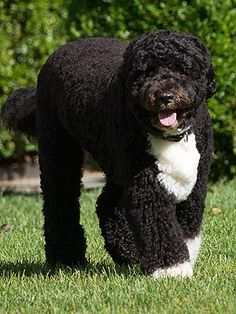

In [83]:
Image.open('/gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog/train/bo/bo_1.jpg')

In [ ]:
# Use the dataset's query_similar method
similar_view = bo_dataset.sort_by_similarity(
  a_sample.id,
  brain_key="vgg16_imagenet_cosine_similarity_index",
  k=5,  # Return top k similar images
  reverse=False  # Most similar first
)

bo_dataset.save_view('most_similar_to_first_sample', similar_view)

In [85]:
similar_view

Dataset:     bo-dataset
View name:   most_similar_to_first_sample
Media type:  image
Num samples: 5
Sample fields:
    id:                         fiftyone.core.fields.ObjectIdField
    filepath:                   fiftyone.core.fields.StringField
    tags:                       fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                 fiftyone.core.fields.DateTimeField
    last_modified_at:           fiftyone.core.fields.DateTimeField
    ground_truth:               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    vgg16-imagenet-predictions: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    vgg16-imagenet-embeddings:  fiftyone.core.fields.VectorField
View stages:
    1. SortBySimilarity(query='6874e5514bb43cd509913ac2', k=5, reverse=False, dist_field=None, brain_key='v

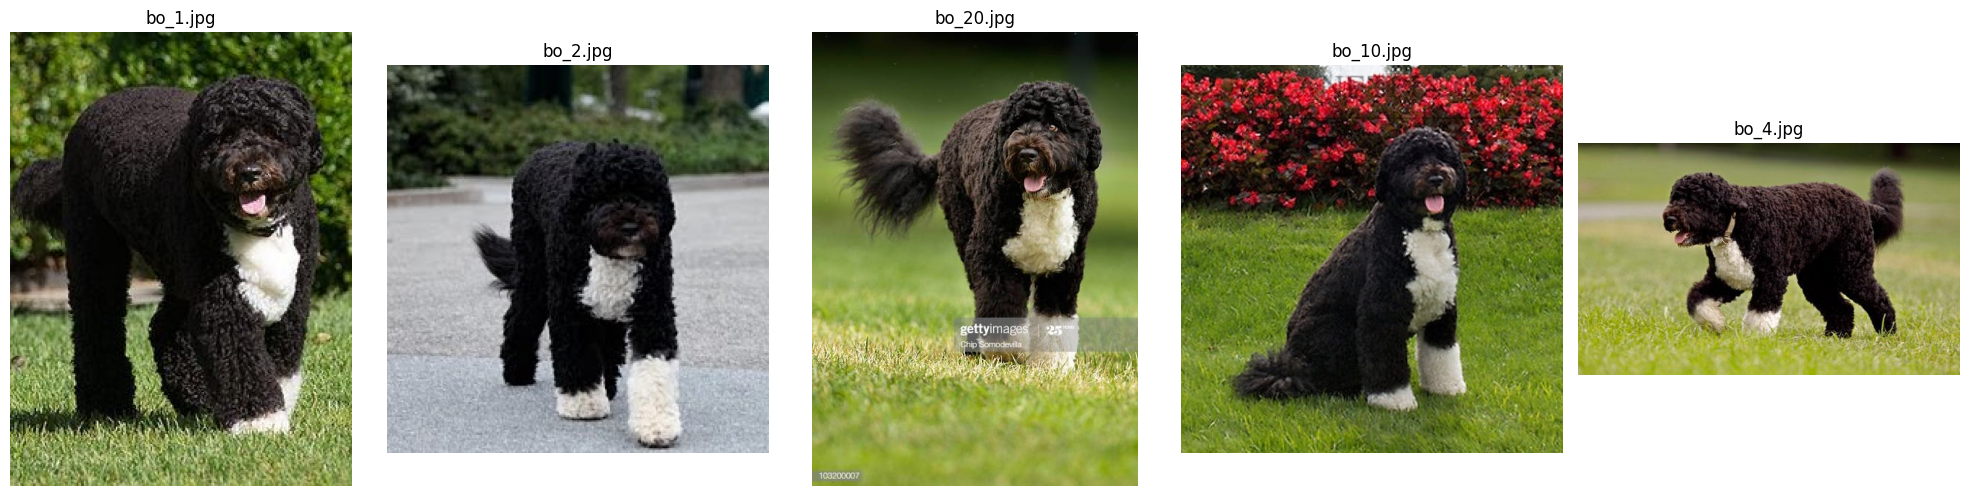

In [86]:
import matplotlib.pyplot as plt
# Get the filepaths of the images in the similar_view
image_paths = [sample.filepath for sample in similar_view]

# Create a figure and a grid of subplots
num_images = len(image_paths)
fig, axes = plt.subplots(1, num_images, figsize=(20, 5)) # Adjust figsize as needed

# Handle case where there's only one image
if num_images == 1:
    axes = [axes]

# Iterate through the filepaths and plot each image
for ax, img_path in zip(axes, image_paths):
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path)) # Set title to filename
        ax.axis('off') # Hide axes
    except FileNotFoundError:
        print(f"Warning: File not found at {img_path}")
        ax.set_title("Image not found")
        ax.axis('off')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [87]:
visualization = fob.compute_visualization(bo_dataset,
                                          method='pca',
                                          brain_key='vgg_pca')
session.refresh()

Computing embeddings...


INFO:fiftyone.brain.internal.core.utils:Computing embeddings...


 100% |█████████████████| 169/169 [3.0s elapsed, 0s remaining, 60.8 samples/s]       


INFO:eta.core.utils: 100% |█████████████████| 169/169 [3.0s elapsed, 0s remaining, 60.8 samples/s]       


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [88]:
testing_dataset.get_field_schema()

OrderedDict([('id', <fiftyone.core.fields.ObjectIdField at 0x7a16e5b7da50>),
             ('filepath',
              <fiftyone.core.fields.StringField at 0x7a16e5b7f110>),
             ('tags', <fiftyone.core.fields.ListField at 0x7a16e5b7c450>),
             ('metadata',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7a16e5b7fc90>),
             ('created_at',
              <fiftyone.core.fields.DateTimeField at 0x7a15a6d9c710>),
             ('last_modified_at',
              <fiftyone.core.fields.DateTimeField at 0x7a16e5b7fa50>),
             ('ground_truth',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7a16e5b7d5d0>)])

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/bo_embeddings.png?raw=true)

In [89]:
print(session.url)

https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


## Inspecting the pretrained model

In [131]:
model

In [90]:
# The PyTorch model is stored as an attribute inside the FiftyOne model wrapper
model._model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Inspecting the classes on which the model has been pre-trained on

Here we inspect the classes that the VGG16 model was trained on during its pre-training on the ImageNet dataset. This helps us understand what types of objects the model is already capable of recognizing and how relevant its existing knowledge is to our specific task of classifying "Bo" vs. "not Bo". Remember that the breed of Bo is 'Portuguese water dog'.

In [91]:
## Inspecting the weights of model and their associated metadata
weights = VGG16_Weights.IMAGENET1K_V1
dir(weights)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [92]:
# Here we have the classes that are mapped to the 1000 ouput units of the model.
# Notice that we have several breeds of dogs and cats in the taxonomy.
# The breed of Bo (Portuguese Water Dog) is outside of the training distribution.
len(weights.meta), weights.meta

(8,
 {'min_size': (32, 32),
  'categories': ['tench',
   'goldfish',
   'great white shark',
   'tiger shark',
   'hammerhead',
   'electric ray',
   'stingray',
   'cock',
   'hen',
   'ostrich',
   'brambling',
   'goldfinch',
   'house finch',
   'junco',
   'indigo bunting',
   'robin',
   'bulbul',
   'jay',
   'magpie',
   'chickadee',
   'water ouzel',
   'kite',
   'bald eagle',
   'vulture',
   'great grey owl',
   'European fire salamander',
   'common newt',
   'eft',
   'spotted salamander',
   'axolotl',
   'bullfrog',
   'tree frog',
   'tailed frog',
   'loggerhead',
   'leatherback turtle',
   'mud turtle',
   'terrapin',
   'box turtle',
   'banded gecko',
   'common iguana',
   'American chameleon',
   'whiptail',
   'agama',
   'frilled lizard',
   'alligator lizard',
   'Gila monster',
   'green lizard',
   'African chameleon',
   'Komodo dragon',
   'African crocodile',
   'American alligator',
   'triceratops',
   'thunder snake',
   'ringneck snake',
   'hognose 

## Inspecting transformations applied to the input images

Understanding the transformations applied to the input images is important. These transformations, such as resizing, cropping, and normalization, prepare images for the VGG16 model. The model expects input images in a specific format and range based on its ImageNet training. Inspecting these transformations confirms correct data processing before the model receives it.





In [93]:
# These were the transformations applied to image during training
original_transforms = weights.transforms()
original_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [94]:
# This set of transforms is functionally equivalent as the one the comes with original_transforms.
original_transforms_in_order = transforms.Compose([
    transforms.ToImage(),
    # Converts images from the range [0, 255] to [0, 1]
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    transforms.CenterCrop(224)
])

In [95]:
a_sample['filepath']

'/gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog/train/bo/bo_1.jpg'

array([[[ 62,  78,   7],
        [ 56,  71,   2],
        [ 52,  62,   2],
        ...,
        [ 59,  86,  17],
        [ 99, 124,  58],
        [107, 132,  66]],

       [[ 73,  88,  19],
        [ 80,  95,  28],
        [ 77,  88,  28],
        ...,
        [ 47,  74,   7],
        [ 82, 107,  42],
        [ 88, 113,  48]],

       [[103, 120,  52],
        [111, 126,  61],
        [114, 125,  65],
        ...,
        [ 30,  56,   0],
        [ 60,  84,  24],
        [ 68,  92,  32]],

       ...,

       [[160, 167,  99],
        [154, 163,  96],
        [167, 176, 111],
        ...,
        [122, 145,  67],
        [143, 167,  91],
        [132, 159,  82]],

       [[166, 171, 104],
        [149, 156,  89],
        [163, 172, 107],
        ...,
        [133, 154,  77],
        [130, 152,  77],
        [136, 160,  84]],

       [[170, 175, 108],
        [166, 173, 106],
        [189, 195, 131],
        ...,
        [121, 142,  65],
        [118, 140,  65],
        [124, 148,  72]]], dtype=uint8)
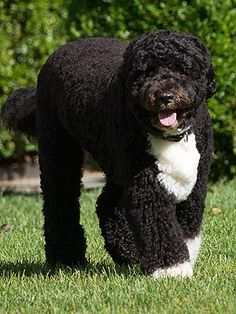

In [96]:
sample_image = Image.open(a_sample['filepath'])
np.array(sample_image)

In [97]:
transformed_input_tensor = original_transforms(sample_image)
transformed_input_tensor

tensor([[[-1.3644, -1.4500, -1.5528,  ..., -1.2959, -1.2617, -1.2617],
         [-1.4158, -1.5357, -1.6555,  ..., -1.4500, -1.4329, -1.4672],
         [-1.4500, -1.5699, -1.6213,  ..., -1.4329, -1.5185, -1.6042],
         ...,
         [ 0.6221,  0.2624, -0.0116,  ..., -0.4397,  0.8618,  1.4269],
         [ 0.3994,  0.0569,  0.0056,  ..., -0.0287,  0.7762,  1.3755],
         [ 0.1939, -0.0801, -0.6623,  ...,  0.2453,  0.8276,  1.2214]],

        [[-1.1429, -1.1779, -1.2304,  ..., -0.8277, -0.7927, -0.7752],
         [-1.1604, -1.2654, -1.3529,  ..., -0.9853, -0.9853, -1.0028],
         [-1.1604, -1.2829, -1.3179,  ..., -0.9503, -1.0203, -1.1078],
         ...,
         [ 1.1506,  0.8179,  0.5378,  ..., -0.0224,  1.3081,  1.8683],
         [ 0.9230,  0.5728,  0.5203,  ...,  0.3978,  1.2206,  1.8333],
         [ 0.7129,  0.4153, -0.1975,  ...,  0.6429,  1.2556,  1.6583]],

        [[-1.6476, -1.5953, -1.5953,  ..., -1.7173, -1.6650, -1.6127],
         [-1.6999, -1.6824, -1.6824,  ..., -1

In [98]:
transformed_input_tensor.shape

torch.Size([3, 224, 224])

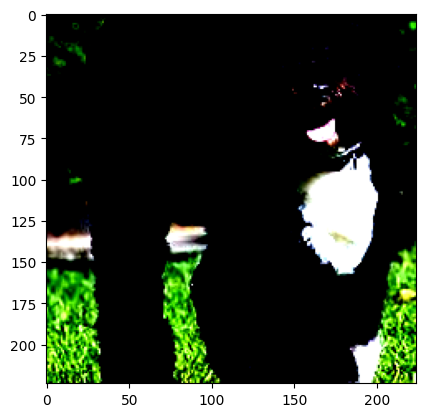

In [99]:
# The model evaluates the images after standard scaling, resizing and center cropping
plt.imshow(transformed_input_tensor.permute(1,2,0))

In [100]:
# FiftyOne has sent the model to the GPU device, if it's available
# We can check this.

# Get the first parameter from the iterator
first_param = next(iter(model._model.parameters()))

# Access the device of the parameter
print(first_param.device)

cuda:0


In [101]:
# We reshape the input tensor to (1, 3, 224, 224) to specify a batch size
reshaped_input_tensor = transformed_input_tensor.reshape(1, 3, 224, 224)
# We send the tensor to the GPU
reshaped_input_tensor_gpu = reshaped_input_tensor.to(device)

In [102]:
# We obtain the logits (scores) out of the model
# Q: What would have happened if we send to the model reshaped_input_tensor?
# Q: What would have happened if we send to the model transformed_input_tensor?
logits = model._model(reshaped_input_tensor_gpu)

In [103]:
# Verify that we have as many logits as there are output units and classes on ImageNet.
# The first dimension corresponds to our batch size
logits.shape

torch.Size([1, 1000])

In [104]:
# Apply Softmax to convert logits to probabilities
probabilities = Fun.softmax(logits, dim=1)

# Get the predicted class index (the one with the highest probability)
predicted_class_index = torch.argmax(probabilities, dim=1).item()

# Get the corresponding label from the ImageNet categories
predicted_label = weights.meta["categories"][predicted_class_index]

print(f"The predicted class index is: {predicted_class_index}")
print(f"The predicted label is: {predicted_label}, with probability {probabilities[0][predicted_class_index].item():.2f}")


The predicted class index is: 267
The predicted label is: standard poodle, with probability 0.44


## Define augmentations for the training set




We define augmentations for the training set to artificially increase the size and variability of our training data. This helps the model generalize better to new, unseen images and reduces overfitting. These transformations can include things like rotation, scaling, and flipping. We visualize the augmentations to the dataset using FiftyOne to get a better sense of what is happening during training.

In [105]:
# Mark the training examples as original
train_view = bo_dataset.match_tags("train")
train_view.tag_samples("original")

In [106]:
# Define augmentations for training images
train_augmentations = A.Compose([

    # Use Affine transform for shifting, scaling, and rotating
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # ±10% translation
        scale=(0.9, 1.1),     # ±10% scaling
        rotate=(-5, 5),     # ±5° rotation
        p=0.8
    ),

    # Elastic deformations to simulate handwriting style variations
    A.ElasticTransform(
        alpha=20,             # Strength of distortion
        sigma=5,              # Smoothness of distortion
        border_mode=cv2.BORDER_CONSTANT,
        p=0.6
    ),

    # Mild perspective transformations
    A.Perspective(scale=(0.01, 0.03), p=0.2),

    # Mild grid distortion
    A.GridDistortion(num_steps=2, distort_limit=0.05, p=0.2),

    # Random horizontal flip (mirroring)
    A.HorizontalFlip(p=0.5),

    # Random change of brightness and contrast
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),

    # Random conversion to grayscale
    A.ToGray(p=0.1)

])

### Create augmentation samples

The samples need to be saved as jpg files for us to visualize them on the FiftyOne app.

In [107]:
# Create a dataset with original and augmented versions for visualization
def create_augmentation_samples(view, augmentations, num_samples=50):
    """Create FiftyOne samples showing original and augmented versions"""

    dataset_name = "augmented_images_training_set"

    if dataset_name in fo.list_datasets():
        aug_viz_dataset = fo.load_dataset(dataset_name)
    else:
        aug_viz_dataset = fo.Dataset(dataset_name)

    sample_paths = view.values("filepath")[:num_samples]
    sample_labels = view.values("ground_truth.label")[:num_samples]

    for i, (path, label) in enumerate(zip(sample_paths, sample_labels)):
        # Load original image
        original_image = Image.open(path).convert('RGB')
        original_np = np.array(original_image)

        # Create sample for original image
        original_sample = fo.Sample(filepath=path)
        original_sample.tags = ["original"]
        original_sample["ground_truth"] = fo.Classification(label=label)
        original_sample["augmentation_type"] = "original"
        aug_viz_dataset.add_sample(original_sample)

        # Create 3 augmented versions
        for aug_idx in range(3):
            # Apply augmentation
            augmented = augmentations(image=original_np)['image']

            # Save augmented image temporarily
            aug_image = Image.fromarray(augmented, mode='RGB')
            temp_path = f"/tmp/aug_{i}_{aug_idx}.png"
            aug_image.save(temp_path)

            # Create FiftyOne sample for augmented image
            aug_sample = fo.Sample(filepath=temp_path)
            aug_sample.tags = ["augmented"]
            aug_sample["ground_truth"] = fo.Classification(label=label)
            aug_sample["augmentation_type"] = f"augmented_{aug_idx + 1}"
            aug_sample["original_sample_id"] = str(i)

            aug_viz_dataset.add_sample(aug_sample)

    return aug_viz_dataset

print("Creating augmentation visualization dataset...")

# Create the visualization dataset
aug_viz_dataset = create_augmentation_samples(
    train_view,
    train_augmentations,
    num_samples=50
)

print(f"Created visualization dataset with {len(aug_viz_dataset)} samples")
print(f"Original samples: {len(aug_viz_dataset.match_tags('original'))}")
print(f"Augmented samples: {len(aug_viz_dataset.match_tags('augmented'))}")



Creating augmentation visualization dataset...
Created visualization dataset with 400 samples
Original samples: 100
Augmented samples: 300


![]()

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/original_augmented_bo.png?raw=true)

In [108]:
# Launch FiftyOne App to visualize the augmentations
session.view = aug_viz_dataset.view()

print(f"\nAugmentation Visualization URL: {session.url}")


Augmentation Visualization URL: https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


## Create the PyTorch Datasets and DataLoaders

In PyTorch, a `Dataset` is an abstract class representing a collection of data samples. It defines two main methods: `__len__`, which returns the number of samples in the dataset, and `__getitem__`, which returns a sample given an index. PyTorch `Dataset`s are designed to provide data samples in a format suitable for training models (typically as PyTorch tensors). They handle the loading and preprocessing of individual data points.

FiftyOne datasets, on the other hand, are designed for managing, visualizing, and analyzing datasets, particularly for computer vision tasks. They store metadata, labels, and links to the actual media files (images, videos). FiftyOne provides powerful tools for exploring data, querying subsets, evaluating models, and identifying issues in your dataset.

The key difference is their primary purpose:

*   **PyTorch Dataset:** Provides data samples for model training and evaluation, focusing on the format and structure needed by PyTorch models.
*   **FiftyOne Dataset:** Manages the dataset itself, providing tools for visualization, exploration, analysis, and organization of data and metadata.

You often use them together: A FiftyOne dataset can be used to manage and curate your data, and then you can create a PyTorch Dataset that wraps the FiftyOne dataset to feed data into a PyTorch model for training.

In [109]:
# Custom PyTorch Dataset class for our binary classification data
class CustomTorchImageDataset(torch.utils.data.Dataset):
    def __init__(self, fiftyone_dataset,
                 image_transforms=None,
                 label_map=None,
                 gt_field="ground_truth"):
        self.fiftyone_dataset = fiftyone_dataset
        self.image_paths = self.fiftyone_dataset.values("filepath")
        self.str_labels = self.fiftyone_dataset.values(f"{gt_field}.label")
        self.image_transforms = image_transforms

        # Define the label map for 'bo' and 'not_bo'
        if label_map is None:
            self.label_map = {"not_bo": 0, "bo": 1}
        else:
            self.label_map = label_map

        print(f"CustomTorchImageDataset initialized with {len(self.image_paths)} samples.")
        print(f"Label map: {self.label_map}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            # Open image as RGB (default for PIL.Image.open)
            image = Image.open(image_path)
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            # Return a dummy tensor and an invalid label in case of error
            # The shape should match the expected input shape after transforms
            # Assuming transforms output (C, H, W)
            # You might need to adjust the dummy tensor shape based on your transforms
            return torch.randn(3, 224, 224), torch.tensor(-1, dtype=torch.long)


        if self.image_transforms:
            image = self.image_transforms(image)

        label_str = self.str_labels[idx]
        label_idx = self.label_map.get(label_str, -1)
        if label_idx == -1:
            print(f"Warning: Label '{label_str}' not in label_map for image {image_path}")
            # Return an invalid label if the label is not in the map
            label_idx = -1


        return image, torch.tensor(label_idx, dtype=torch.long)

In [110]:
# Create a PyTorch dataset from the augmentation visualization dataset
aug_viz_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset=aug_viz_dataset,
    image_transforms=original_transforms_in_order, # Use the same transforms as for validation/testing
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

print("\nAugmentation Visualization PyTorch Dataset created:")
print(f"Number of samples: {len(aug_viz_torch_dataset)}")

CustomTorchImageDataset initialized with 400 samples.
Label map: {'not_bo': 0, 'bo': 1}

Augmentation Visualization PyTorch Dataset created:
Number of samples: 400


### Instantiate PyTorch datasets

The PyTorch dataset wraps together the training images and labels in a tuple of tensors. We present the image tensors to the model in batches. The labels are evaluated on the loss function to determine the quality of the predictions.  

In [111]:
# In FiftyOne, views and datasets can be used interchangebly
train_view = bo_dataset.match_tags("train")
val_view = bo_dataset.match_tags("validation")

print(f"Number of training samples: {len(train_view)}")
print(f"Number of validation samples: {len(val_view)}")

Number of training samples: 70
Number of validation samples: 69


In [112]:
# Define image transformations (using the original VGG16 transformations)
# You can add more augmentations here for training later
train_transforms = original_transforms_in_order # Use the corrected transforms
val_transforms = original_transforms_in_order # Use the corrected transforms

# Create instances of the CustomTorchImageDataset for train and validation
train_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset= train_view, #TODO: compare with aug_viz_dataset
    image_transforms=train_transforms,
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

val_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset=val_view,
    image_transforms=val_transforms,
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

# Define batch size
batch_size = 8

# Create DataLoaders
train_dataloader = DataLoader(
    train_torch_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffle training data
    num_workers=2 # Use multiple workers for faster data loading
)

val_dataloader = DataLoader(
    val_torch_dataset,
    batch_size=batch_size,
    shuffle=False, # Do not shuffle validation data
    num_workers=2 # Use multiple workers for faster data loading
)

print("\nDataLoaders created:")
print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Validation DataLoader: {len(val_dataloader)} batches of size {batch_size}")

CustomTorchImageDataset initialized with 70 samples.
Label map: {'not_bo': 0, 'bo': 1}
CustomTorchImageDataset initialized with 69 samples.
Label map: {'not_bo': 0, 'bo': 1}

DataLoaders created:
Train DataLoader: 9 batches of size 8
Validation DataLoader: 9 batches of size 8


## Change the model's final layers



Since we are adapting the pre-trained VGG16 model for a new binary classification task ("Bo" vs. "not Bo"), we need to modify its final layers. The original model was trained to classify 1000 ImageNet categories. We replace the last classification layer with new layers suitable for our two classes. We also freeze the weights of the original VGG16 layers so that only the new layers are trained on our dataset, which is a common technique in transfer learning.

This changes could also be done on `model._model`(the vgg16 model that we used already). We keep things separate for consistency now.  

In [113]:
new_model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
new_model


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [114]:
# Freeze all base layers in the VGG16 model
for param in new_model.parameters():
    param.requires_grad = False

print("All VGG16 base layers have been frozen.")

All VGG16 base layers have been frozen.


In [115]:
## Replace the classifier layers
new_model.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=4096, bias=True),
    nn.ReLU(inplace=True),
    nn.Linear(in_features=4096, out_features=1, bias=True)
    )

In [116]:
# The new randomly initialized weights are unfrozen (trainable)
for param in new_model.classifier.parameters():
    print(param.requires_grad)

True
True
True
True


In [117]:
# Send the new model to the GPU, if available
new_model = new_model.to(device)

## Train and checkpoint the model

We train the modified VGG16 model on our "Bo" vs. "not Bo" dataset. Training involves feeding the data through the model, calculating the loss (how far off the predictions are), and updating the model's weights to minimize the loss. Checkpointing involves saving the model's weights periodically, especially when the model performs best on the validation set. This allows us to resume training later or use the best-performing model for inference.

### Define the loss function and optimizer

We define the loss function and optimizer that will be used to train the model. The loss function measures the difference between the model's predictions and the actual labels, guiding the training process to minimize this error. The optimizer is responsible for updating the model's weights based on the calculated gradients of the loss function.

#### Binary Cross Entropy Loss

In [118]:
# We use binary cross entropy loss from logits
# https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
ce_loss = torch.nn.BCEWithLogitsLoss()

The binary cross entropy loss (BCE) is defined as:

$$
\text{BCE}(y, \hat{y}) = - \frac{1}{N} \sum_{i=1}^N [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]
$$

where:
- $N$ is the number of samples in the batch
- $y_i$ is the true label for sample $i$ (0 or 1)
- $\hat{y}_i$ is the predicted probability for sample $i$

In PyTorch, [`BCEWithLogitsLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)receives inputs that correspond to the outputs of the final layer of the model. This set of outputs are called 'logits' and correspond to scores. These scores get turned into probabilities after going through a [Sigmoid activation function](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html).

#### The ADAM optimizer

In [119]:
# Define the optimizer (variant of stochastic gradient descent)
optimizer = Adam(new_model.parameters(),
                 lr=0.003, betas=(0.9, 0.999),
                 eps=1e-08, weight_decay=0)


The Adam optimizer is a popular optimization algorithm that is an extension to stochastic gradient descent. It adaptively estimates lower-order moments (mean and variance) of the gradients.

The settings used here are:

*   `lr=0.003`: This is the learning rate, which determines the step size at each iteration while moving towards a minimum of the loss function. A smaller learning rate requires more training epochs but can lead to a more stable model. A larger learning rate can converge faster but might overshoot the minimum.
*   `betas=(0.9, 0.999)`: These are the exponential decay rates for the first and second moment estimates. `beta1` (0.9) is for the first moment (mean) and `beta2` (0.999) is for the second moment (variance). These values control how quickly the algorithm forgets past gradients.
*   `eps=1e-08`: This is a small constant added to the denominator for numerical stability to prevent division by zero.
*   `weight_decay=0`: This is the L2 penalty (regularization). A value of 0 means no weight decay is applied. Weight decay helps to prevent overfitting by penalizing large weights.

### Defining a training epoch

The `train_epoch` function defines a single pass over the training dataset. In each epoch, the model processes the data in batches. For each batch, it calculates the loss, computes the gradients, and updates the model's weights using the optimizer to minimize the loss. The average loss over all batches in the epoch is returned.

In [120]:
def train_epoch(model, train_loader):
  batch_losses = []
  model.train()
  for images, labels in tqdm(train_loader, desc="Training: "):
      #import pdb; pdb.set_trace()

      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      # Unsqueeze labels to match logits shape [batch_size, 1]
      loss_value = ce_loss(logits, labels.unsqueeze(1).float())
      # Clear gradients from previous iteration (PyTorch accumulates by default)
      optimizer.zero_grad()
      # Computes the gradients with backpropagation
      loss_value.backward()
      # Updates the weights
      optimizer.step()

      batch_losses.append(loss_value.item())

  train_loss = np.mean(batch_losses)
  return train_loss

### Defining a validation epoch

The `val_epoch` function defines a single pass over the validation dataset. In each epoch, the model processes the data in batches and calculates the loss to evaluate performance without updating the model's weights. The average loss over all batches in the epoch is returned.

In [121]:
def val_epoch(model, val_loader):
  batch_losses = []
  model.eval()
  with torch.inference_mode():
    for images, labels in tqdm(val_loader, desc="Validation: "):
      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      # Unsqueeze labels to match logits shape [batch_size, 1]
      loss_value = ce_loss(logits, labels.unsqueeze(1).float())
      batch_losses.append(loss_value.item())
  val_loss = np.mean(batch_losses)
  return val_loss

## Training loop

The training loop iterates over a specified number of epochs. In each epoch, it calls the `train_epoch` function to train the model on the training data and the `val_epoch` function to evaluate the model on the validation data. It keeps track of the training and validation losses and saves the model's state dictionary whenever a new best validation loss is achieved.

In [122]:
# Ensure reproducibility for the training process
set_seeds(51) # You can change this number to get different results

num_epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model = None

# Define the path to save the model within your hard-drive
path = Path(os.getcwd()) # Feel free to change the path

model_save_path = path / 'best_vgg16.pth'

for epoch in range(num_epochs):
    train_loss = train_epoch(new_model, train_dataloader)
    val_loss = val_epoch(new_model, val_dataloader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = new_model
        # Save the best model
        torch.save(best_model.state_dict(), model_save_path)
        print('Found and saved better weights for the model')

All random seeds set to 51 for reproducibility


Validation: 100%|██████████| 9/9 [00:00<00:00, 12.23it/s]


Epoch 1/10 - Train Loss: 0.7101 - Val Loss: 2.8866
Found and saved better weights for the model


Validation: 100%|██████████| 9/9 [00:00<00:00, 12.46it/s]


Epoch 2/10 - Train Loss: 8.6406 - Val Loss: 2.9094


...

Epoch 8/10 - Train Loss: 0.0000 - Val Loss: 0.0000


Validation: 100%|██████████| 9/9 [00:00<00:00, 12.60it/s]


Epoch 9/10 - Train Loss: 0.0000 - Val Loss: 0.0005


Validation: 100%|██████████| 9/9 [00:00<00:00, 12.19it/s]

Epoch 10/10 - Train Loss: 0.0000 - Val Loss: 0.4334


## Visualizing training and validation losses



After training, we visualize the training and validation losses over epochs. This plot helps us monitor the model's learning progress, identify potential issues like overfitting (where training loss decreases but validation loss increases), and determine the optimal number of training epochs. The red line indicates the epoch where the best validation loss was achieved, and the model weights at this epoch are saved.

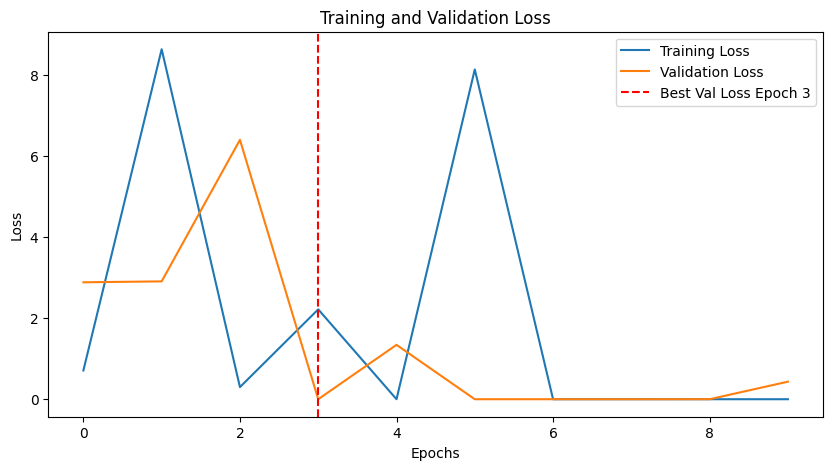

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Find the epoch with the best validation loss
best_epoch = np.argmin(val_losses)

# Add a vertical red line at the epoch with the best validation loss
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Val Loss Epoch {best_epoch}')
plt.legend()

plt.show()

## Apply predictions to the test set

After training and evaluating the model on the training and validation sets, we apply the best-performing model to the independent test set. This step assesses the model's ability to generalize to completely data and provides a final measure of its performance on the task of classifying "Bo" vs. "not Bo".

In [124]:
def load_best_model(model_path, device):
    """
    Load the best saved model from checkpoint.

    Args:
        model_path (Path): Path to the saved model state dict
        device (torch.device): Device to load the model on

    Returns:
        torch.nn.Module: Loaded model ready for inference
    """
    # Recreate the model architecture (same as training)
    from torchvision.models import vgg16, VGG16_Weights

    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    # Replace classifier to match our binary classification setup
    model.classifier = nn.Sequential(
        nn.Linear(in_features=25088, out_features=4096, bias=True),
        nn.ReLU(inplace=True),
        nn.Linear(in_features=4096, out_features=1, bias=True)
    )

    # Load the saved state dict
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()  # Set to evaluation mode

    print(f"Model loaded successfully from {model_path}")
    return model



In [125]:
def predict_on_fiftyone_dataset(model, fo_dataset, transforms, device,
                               confidence_threshold=0.5, label_map=None):
    """
    Make predictions on a FiftyOne dataset and return predictions with confidence scores.

    Args:
        model (torch.nn.Module): Trained model
        fo_dataset (fiftyone.Dataset): FiftyOne dataset to predict on
        transforms: Image transformations to apply
        device (torch.device): Device for inference
        confidence_threshold (float): Threshold for binary classification
        label_map (dict): Mapping from class indices to labels

    Returns:
        list: List of dictionaries containing predictions and confidence scores
    """
    if label_map is None:
        label_map = {0: "not_bo", 1: "bo"}

    predictions = []

    # Get all image paths from the FiftyOne dataset
    image_paths = fo_dataset.values("filepath")

    print(f"Making predictions on {len(image_paths)} images...")

    with torch.no_grad():
        for image_path in tqdm(image_paths, desc="Predicting"):
            try:
                # Load and preprocess image
                image = Image.open(image_path).convert('RGB')
                image_tensor = transforms(image).unsqueeze(0).to(device)  # Add batch dimension

                # Make prediction
                logit = model(image_tensor)
                probability = torch.sigmoid(logit).item()  # Convert logit to probability

                # Determine predicted class
                predicted_class_idx = 1 if probability >= confidence_threshold else 0
                predicted_label = label_map[predicted_class_idx]

                # Store prediction info
                prediction_info = {
                    'label': predicted_label,
                    'confidence': probability if predicted_class_idx == 1 else (1 - probability),
                    'bo_probability': probability,  # Probability of being Bo
                    'not_bo_probability': 1 - probability  # Probability of not being Bo
                }

                predictions.append(prediction_info)

            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                # Add a default prediction for failed cases
                predictions.append({
                    'label': 'not_bo',  # Default to not_bo
                    'confidence': 0.0,
                    'bo_probability': 0.0,
                    'not_bo_probability': 1.0
                })

    return predictions



In [126]:
def add_predictions_to_fiftyone_dataset(fo_dataset, predictions,
                                        field_name="fine_tuned_vgg16_prediction"):
    """
    Add predictions to a FiftyOne dataset as Classification objects.

    Args:
        fo_dataset (fiftyone.Dataset): FiftyOne dataset to add predictions to
        predictions (list): List of prediction dictionaries
        field_name (str): Name of the field to store predictions
    """
    print(f"Adding predictions to FiftyOne dataset under field '{field_name}'...")

    # Iterate through samples and add predictions
    for sample, prediction in tqdm(zip(fo_dataset, predictions),
                                  total=len(fo_dataset),
                                  desc="Adding predictions"):
        # Create FiftyOne Classification object
        classification = fo.Classification(
            label=prediction['label'],
            confidence=prediction['confidence']
        )

        # Add additional metadata
        classification['bo_probability'] = prediction['bo_probability']
        classification['not_bo_probability'] = prediction['not_bo_probability']

        # Set the prediction field
        sample[field_name] = classification
        sample.save()

    print(f"Predictions successfully added to '{field_name}' field!")



In [127]:
test_view = bo_dataset.match_tags("test")
session.view = test_view
print(f"\nTest View URL: {session.url}")



Test View URL: https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


In [133]:
# Load the best saved model
best_model = load_best_model(model_save_path, device)

# Define transforms for the test set (same as validation)
test_transforms = original_transforms_in_order

# Make predictions on the test dataset
test_predictions = predict_on_fiftyone_dataset(
    best_model,
    test_view,
    test_transforms,
    device,
    # Use 0.5 as the threshold for binary classification probability
    confidence_threshold=0.5,
    # Explicitly define label map for clarity
    label_map={0: "not_bo", 1: "bo"}
)

# Add the predictions to the FiftyOne test dataset
add_predictions_to_fiftyone_dataset(test_view, test_predictions)

# Refresh the FiftyOne app session to see the new predictions
session.view = testing_dataset.view()
session.refresh()



Model loaded successfully from /content/best_vgg16.pth
Making predictions on 30 images...


Predicting: 100%|██████████| 30/30 [00:00<00:00, 44.48it/s]


Adding predictions to FiftyOne dataset under field 'fine_tuned_vgg16_prediction'...


Adding predictions: 100%|██████████| 30/30 [00:00<00:00, 313.39it/s]


Predictions successfully added to 'fine_tuned_vgg16_prediction' field!


In [142]:
# Check if any samples are missing predictions
samples_without_predictions = test_view.exists("fine_tuned_vgg16_prediction", False)
print(f"Samples without predictions: {len(samples_without_predictions)}")

# Check if any samples have None ground truth
samples_without_gt = test_view.exists("ground_truth", False)
print(f"Samples without ground truth: {len(samples_without_gt)}")

Samples without predictions: 0
Samples without ground truth: 0


In [134]:
# We can check that the predictions appear now on the samples
test_view.first()

<SampleView: {
    'id': '6874e5514bb43cd509913b6d',
    'media_type': 'image',
    'filepath': '/gdrive/MyDrive/fiftyone-getting-started-datasets/presidential-dog/test/bo/bo_20.jpg',
    'tags': ['test'],
    'metadata': <ImageMetadata: {
        'size_bytes': 37323,
        'mime_type': 'image/jpeg',
        'width': 439,
        'height': 612,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 7, 14, 11, 9, 5, 546000),
    'last_modified_at': datetime.datetime(2025, 7, 14, 11, 30, 8, 490000),
    'ground_truth': <Classification: {
        'id': '6874e8cd7463c421d9a3c0bb',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-predictions': <Classification: {
        'id': '6874e8d37463c421d9a3c187',
        'tags': [],
        'label': 'Kerry blue terrier',
        'confidence': 0.16190096735954285,
        'logits': None,
    }>,
    'vgg16-imagenet-embeddings': array([0., 0., 0., ..., 0.,

In [135]:
# Evaluate the predictions in the `predictions` field with respect to the
# labels in the `ground_truth` field
results = test_view.evaluate_classifications(
    "fine_tuned_vgg16_prediction",
    gt_field="ground_truth",
    eval_key="eval_simple",
)

# Print a classification report
results.print_report()

# Plot a confusion matrix
plot = results.plot_confusion_matrix()
plot.show()



              precision    recall  f1-score   support

          bo       1.00      0.90      0.95        10
      not_bo       0.95      1.00      0.98        20

    accuracy                           0.97        30
   macro avg       0.98      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.11/dist-packages/fiftyone/core/plots/plotly.py:1591: UserWarning:

Interactive plots are currently only supported in Jupyter notebooks. Support outside of notebooks and in Google Colab and Databricks will be included in an upcoming release. In the meantime, you can still use this plot, but note that (i) selecting data will not trigger callbacks, and (ii) you must manually call `plot.show()` to launch a new plot that reflects the current state of an attached session.

See https://docs.voxel51.com/user_guide/plots.html#working-in-notebooks for more information.

/usr/local/lib/python3.11/dist-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




![](https://github.com/andandandand/practical-computer-vision/blob/main/images/bo_mistakes.png?raw=1)

In [136]:
session.view = test_view
print(session.url)

https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


## Save your work in a local directory

In [137]:
save_path = Path('/gdrive/MyDrive/fiftyone-saved-work')
os.listdir(save_path)

['bo-dataset']

In [138]:
bo_dataset.export(
    export_dir=str(save_path / "bo-dataset"),
    dataset_type=fo.types.FiftyOneDataset,
    split_types=["train", "validation", "test"],
    export_media=True

)

print(f"Dataset '{bo_dataset.name}' exported to {save_path / 'bo-dataset'}")

Directory '/gdrive/MyDrive/fiftyone-saved-work/bo-dataset' already exists; export will be merged with existing files


Ignoring unsupported parameter 'split_types'


Exporting samples...


INFO:fiftyone.utils.data.exporters:Exporting samples...


 100% |████████████████████| 169/169 [42.2s elapsed, 0s remaining, 4.4 docs/s]      


INFO:eta.core.utils: 100% |████████████████████| 169/169 [42.2s elapsed, 0s remaining, 4.4 docs/s]      


Dataset 'bo-dataset' exported to /gdrive/MyDrive/fiftyone-saved-work/bo-dataset


In [139]:
session.dataset = bo_dataset
print(session.url)

https://5151-gpu-t4-hm-7si9x9t5c8ru-c.us-east1-1.prod.colab.dev?polling=true


## Pushing to HuggingFace Hub

In [141]:
from fiftyone.utils.huggingface import push_to_hub

push_to_hub(bo_dataset,
            'bo_or_not',
            license='mit',
            chunk_size=100,
            exist_ok=True,
            overwrite=True
            )

Directory '/tmp/tmp8ic_8d2x' already exists; export will be merged with existing files


Exporting samples...


INFO:fiftyone.utils.data.exporters:Exporting samples...


 100% |████████████████████| 169/169 [461.2ms elapsed, 0s remaining, 366.4 docs/s]      


INFO:eta.core.utils: 100% |████████████████████| 169/169 [461.2ms elapsed, 0s remaining, 366.4 docs/s]      
No files have been modified since last commit. Skipping to prevent empty commit.
Uploading media files in 2 batches of size 100: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


## References

* [FiftyOne documentation](https://docs.voxel51.com/)
* [Google's Machine Learning Glossary](https://developers.google.com/machine-learning/glossary)
* [PyTorch Tutorials](https://docs.pytorch.org/tutorials/)
* [Getting Started with FiftyOne YouTube Playlist](https://youtu.be/Iy_oYIrQefs?si=mHmR5sZAXJpbk0ZB)